In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid", palette="muted")

# Load data
df = pd.read_csv("../data/raw/weather_toba_2015_2024.csv", parse_dates=["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")

print(f"Dataset loaded: {len(df):,} baris, {df['location'].nunique()} lokasi")
print(f"Periode: {df['date'].min().date()} s/d {df['date'].max().date()}")
df.head(3)

Dataset loaded: 18,265 baris, 5 lokasi
Periode: 2015-01-01 s/d 2024-12-31


,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,winddirection_10m_dominant,weathercode,et0_fao_evapotranspiration,date,location,lat,lon,year,month,month_name
0,28.3,27.3,27.8,0.0,7.4,79,3,4.75,2015-01-01,Balige (Tobasa),-2.3333,99.0667,2015,1,Jan
1,28.2,27.4,27.8,0.0,8.2,246,3,4.77,2015-01-02,Balige (Tobasa),-2.3333,99.0667,2015,1,Jan
2,28.0,26.3,27.3,3.3,22.0,298,55,4.27,2015-01-03,Balige (Tobasa),-2.3333,99.0667,2015,1,Jan


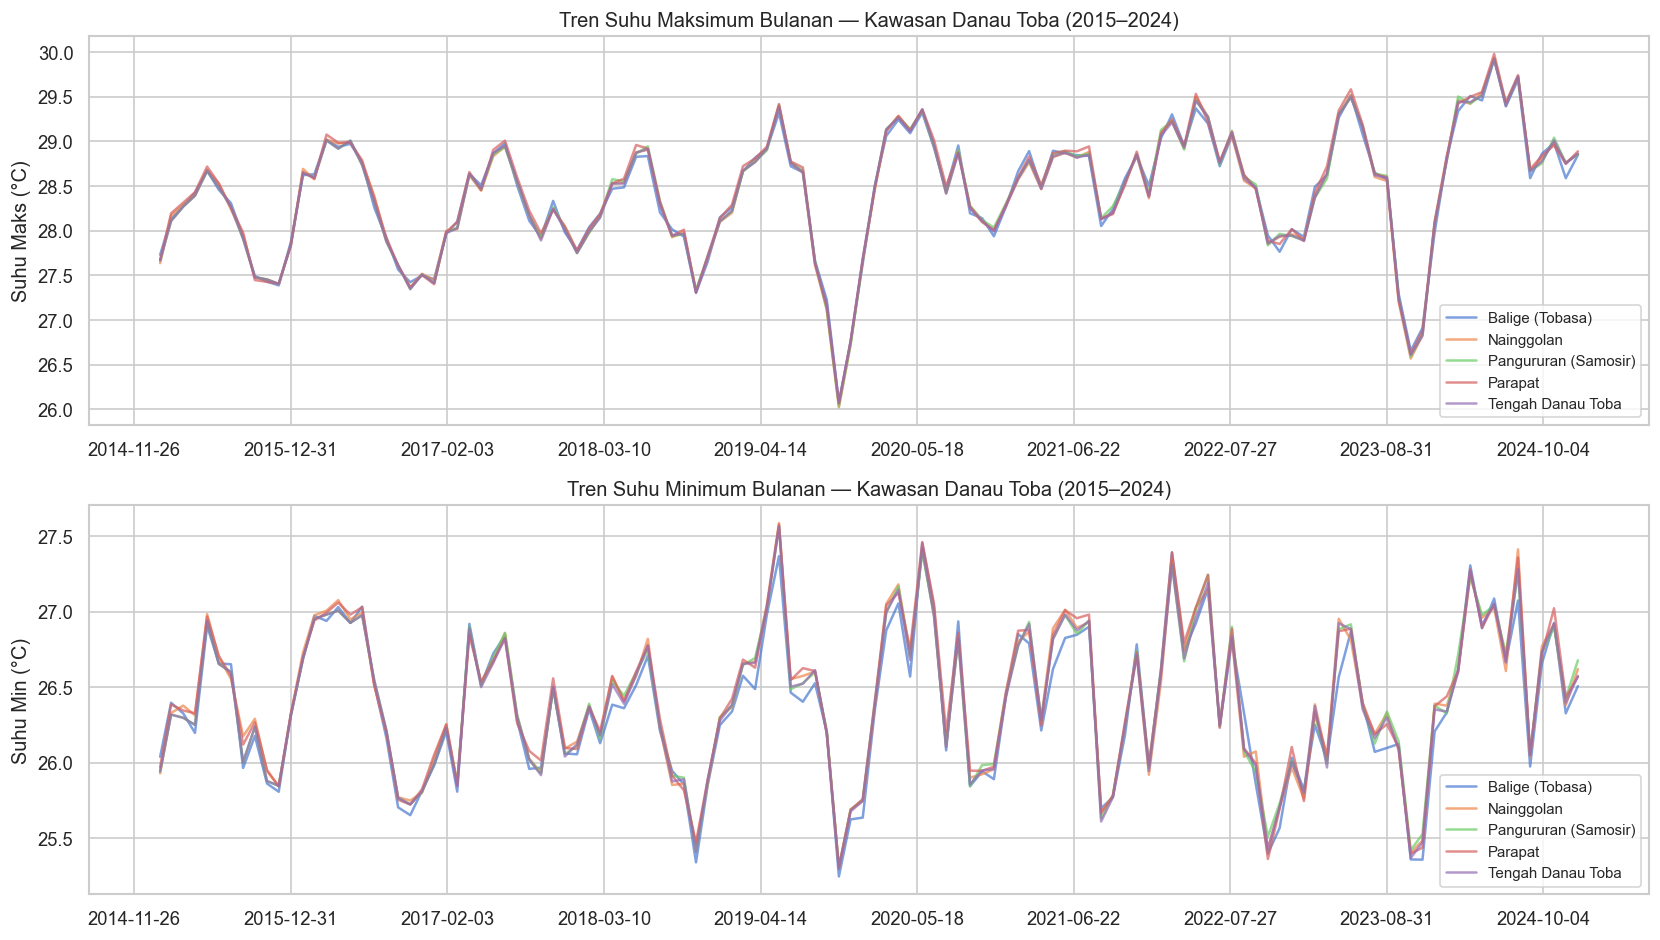

Chart disimpan ke data/processed/01_tren_suhu.png


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot suhu max & min per lokasi (rata-rata bulanan)
for loc in df["location"].unique():
    subset = df[df["location"] == loc].copy()
    monthly = subset.resample("ME", on="date").agg(
        temp_max=("temperature_2m_max", "mean"),
        temp_min=("temperature_2m_min", "mean")
    )
    axes[0].plot(monthly.index, monthly["temp_max"], alpha=0.7, label=loc)
    axes[1].plot(monthly.index, monthly["temp_min"], alpha=0.7, label=loc)

axes[0].set_title("Tren Suhu Maksimum Bulanan — Kawasan Danau Toba (2015–2024)")
axes[0].set_ylabel("Suhu Maks (°C)")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(10))

axes[1].set_title("Tren Suhu Minimum Bulanan — Kawasan Danau Toba (2015–2024)")
axes[1].set_ylabel("Suhu Min (°C)")
axes[1].legend(fontsize=9, loc="lower right")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(10))

plt.tight_layout()
plt.savefig("../data/processed/01_tren_suhu.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart disimpan ke data/processed/01_tren_suhu.png")

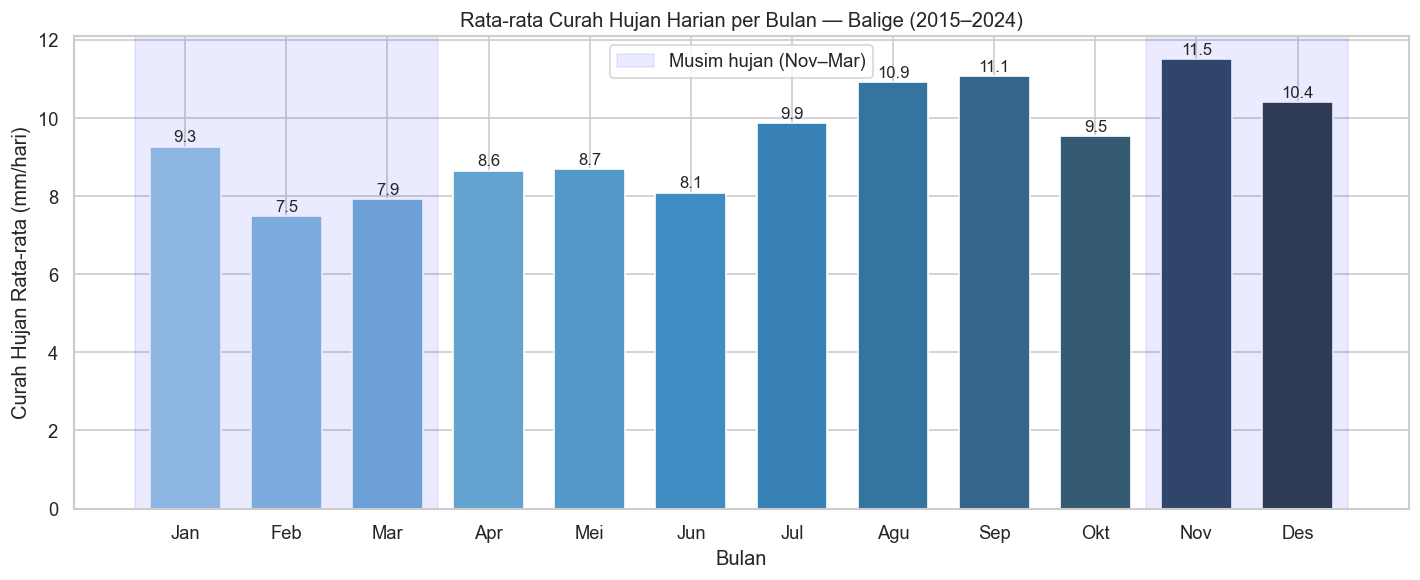

In [3]:
# Fokus ke satu lokasi representatif: Balige
balige = df[df["location"] == "Balige (Tobasa)"].copy()

monthly_rain = balige.groupby("month")["precipitation_sum"].mean().reset_index()
month_labels = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
monthly_rain["month_name"] = month_labels

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_rain["month_name"], monthly_rain["precipitation_sum"],
              color=sns.color_palette("Blues_d", 12), edgecolor="white", width=0.7)

# Label nilai di atas bar
for bar, val in zip(bars, monthly_rain["precipitation_sum"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Rata-rata Curah Hujan Harian per Bulan — Balige (2015–2024)")
ax.set_ylabel("Curah Hujan Rata-rata (mm/hari)")
ax.set_xlabel("Bulan")

# Tandai musim hujan
ax.axvspan(-0.5, 2.5, alpha=0.08, color="blue", label="Musim hujan (Nov–Mar)")
ax.axvspan(9.5, 11.5, alpha=0.08, color="blue")
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/02_pola_hujan_bulanan.png", dpi=150, bbox_inches="tight")
plt.show()

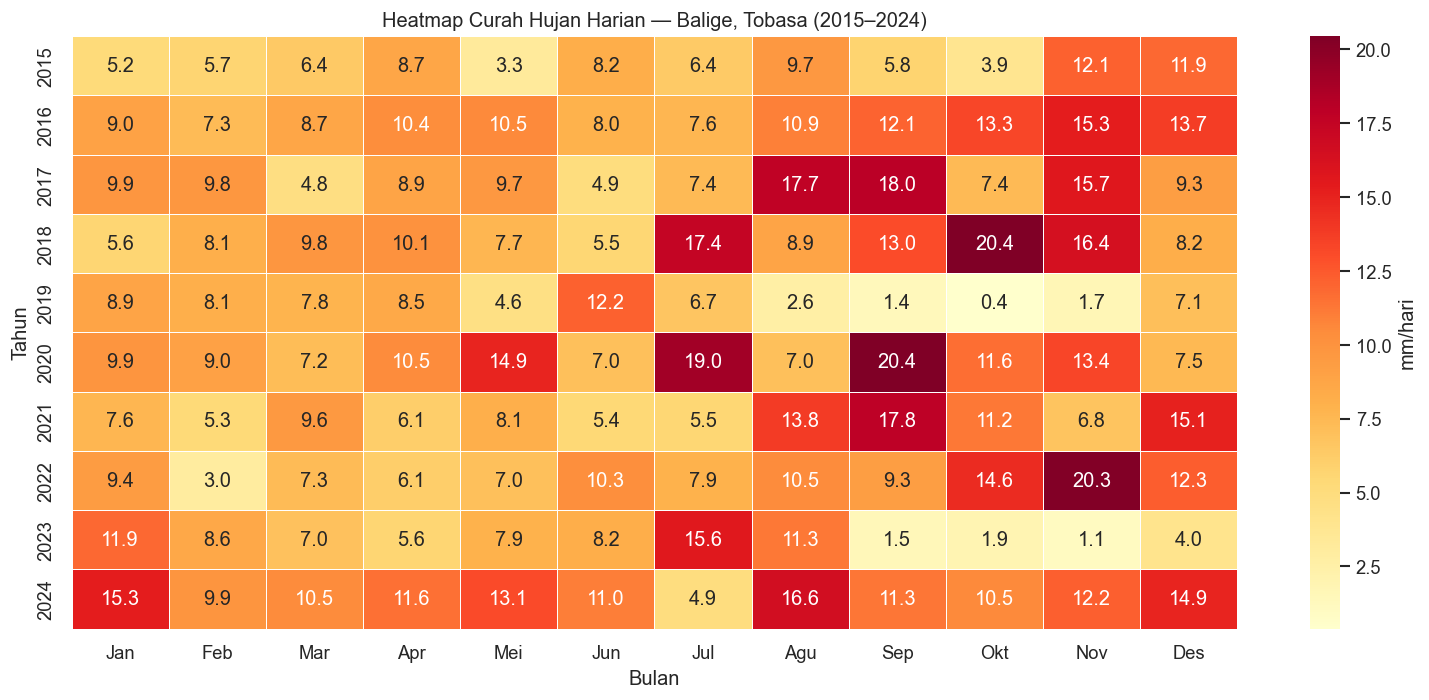

Heatmap menunjukkan pola musiman curah hujan per tahun


In [4]:
# Pivot: baris = tahun, kolom = bulan
pivot_rain = balige.pivot_table(
    values="precipitation_sum",
    index="year",
    columns="month",
    aggfunc="mean"
)
pivot_rain.columns = month_labels

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_rain,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "mm/hari"}
)
ax.set_title("Heatmap Curah Hujan Harian — Balige, Tobasa (2015–2024)")
ax.set_ylabel("Tahun")
ax.set_xlabel("Bulan")

plt.tight_layout()
plt.savefig("../data/processed/03_heatmap_hujan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap menunjukkan pola musiman curah hujan per tahun")

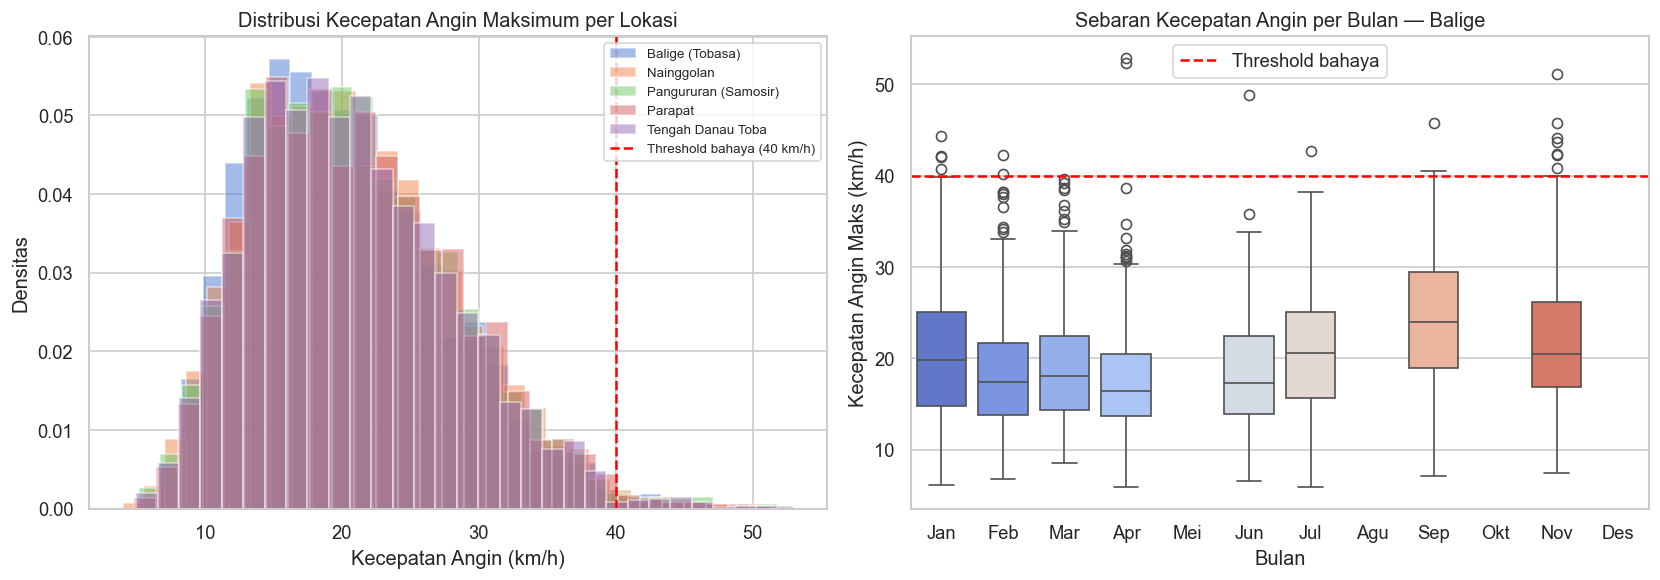

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram angin semua lokasi
for loc in df["location"].unique():
    subset = df[df["location"] == loc]
    axes[0].hist(subset["windspeed_10m_max"], bins=30, alpha=0.5, label=loc, density=True)

axes[0].set_title("Distribusi Kecepatan Angin Maksimum per Lokasi")
axes[0].set_xlabel("Kecepatan Angin (km/h)")
axes[0].set_ylabel("Densitas")
axes[0].axvline(40, color="red", linestyle="--", linewidth=1.5, label="Threshold bahaya (40 km/h)")
axes[0].legend(fontsize=8)

# Boxplot angin per bulan (Balige)
balige_wind = balige.copy()
balige_wind["month_name"] = pd.Categorical(
    balige_wind["month_name"], categories=month_labels, ordered=True
)
sns.boxplot(data=balige_wind, x="month_name", y="windspeed_10m_max",
            palette="coolwarm", ax=axes[1])
axes[1].set_title("Sebaran Kecepatan Angin per Bulan — Balige")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("Kecepatan Angin Maks (km/h)")
axes[1].axhline(40, color="red", linestyle="--", linewidth=1.5, label="Threshold bahaya")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/04_distribusi_angin.png", dpi=150, bbox_inches="tight")
plt.show()

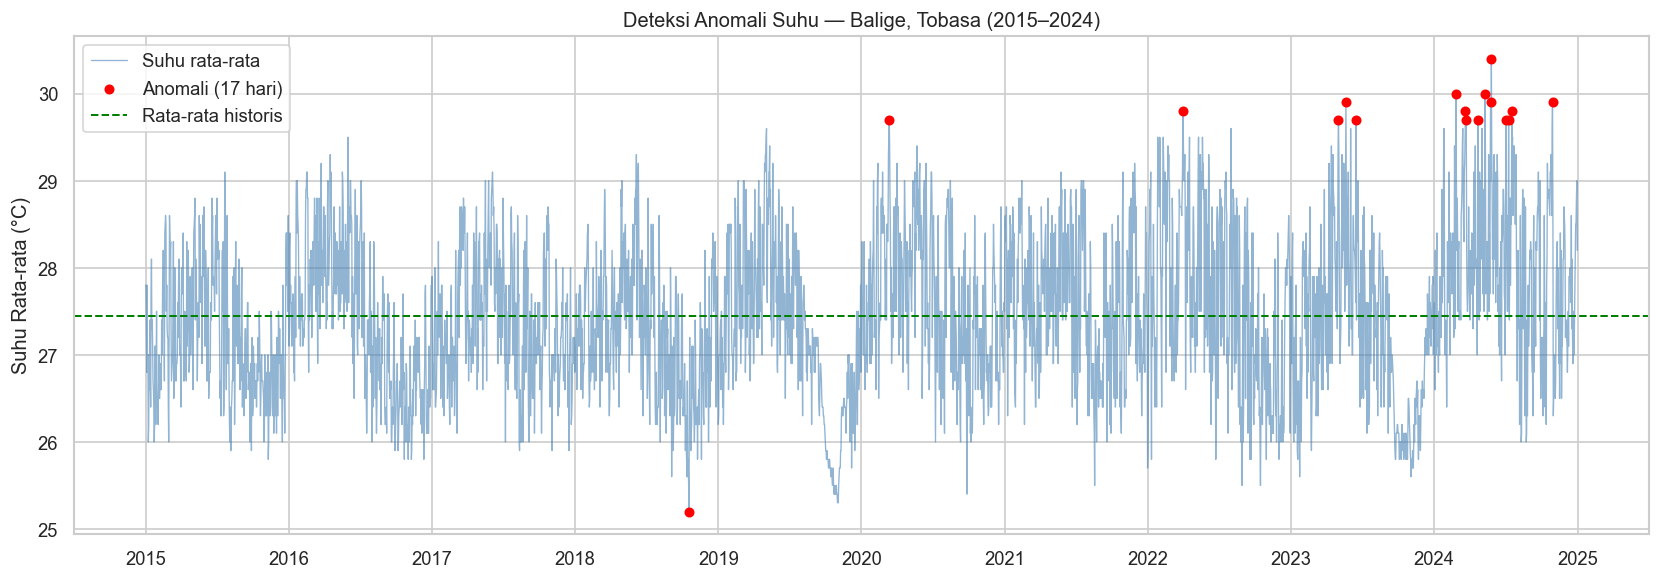


Total hari anomali suhu (z-score > 2.5): 17
      date  temperature_2m_mean  temp_zscore
2018-10-18                 25.2    -2.541194
2020-03-12                 29.7     2.544381
2022-03-31                 29.8     2.657393
2023-05-02                 29.7     2.544381
2023-05-21                 29.9     2.770406
2023-06-16                 29.7     2.544381
2024-02-26                 30.0     2.883419
2024-03-21                 29.8     2.657393
2024-03-23                 29.7     2.544381
2024-04-22                 29.7     2.544381
2024-05-10                 30.0     2.883419
2024-05-24                 29.9     2.770406
2024-05-26                 30.4     3.335470
2024-07-03                 29.7     2.544381
2024-07-09                 29.7     2.544381
2024-07-17                 29.8     2.657393
2024-10-29                 29.9     2.770406


In [6]:
# Hitung z-score suhu untuk deteksi anomali
balige["temp_zscore"] = (
    balige["temperature_2m_mean"] - balige["temperature_2m_mean"].mean()
) / balige["temperature_2m_mean"].std()

anomali = balige[balige["temp_zscore"].abs() > 2.5].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(balige["date"], balige["temperature_2m_mean"],
        color="steelblue", alpha=0.6, linewidth=0.8, label="Suhu rata-rata")
ax.scatter(anomali["date"], anomali["temperature_2m_mean"],
           color="red", s=25, zorder=5, label=f"Anomali ({len(anomali)} hari)")
ax.axhline(balige["temperature_2m_mean"].mean(), color="green",
           linestyle="--", linewidth=1.2, label="Rata-rata historis")

ax.set_title("Deteksi Anomali Suhu — Balige, Tobasa (2015–2024)")
ax.set_ylabel("Suhu Rata-rata (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/05_anomali_suhu.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal hari anomali suhu (z-score > 2.5): {len(anomali)}")
print(anomali[["date", "temperature_2m_mean", "temp_zscore"]].to_string(index=False))

In [7]:
print("   RINGKASAN EDA — KAWASAN DANAU TOBA (2015–2024)")

stats = balige[["temperature_2m_max", "temperature_2m_min",
                "precipitation_sum", "windspeed_10m_max"]].describe().round(2)

labels = {
    "temperature_2m_max" : "Suhu Maks (°C)",
    "temperature_2m_min" : "Suhu Min (°C)",
    "precipitation_sum"  : "Curah Hujan (mm)",
    "windspeed_10m_max"  : "Angin Maks (km/h)"
}
stats = stats.rename(columns=labels)
print(stats.T)

print(f"\nBulan terbasah  : {month_labels[monthly_rain.loc[monthly_rain['precipitation_sum'].idxmax(), 'month'] - 1]} "
      f"({monthly_rain['precipitation_sum'].max():.1f} mm/hari rata-rata)")
print(f"Bulan terkering : {month_labels[monthly_rain.loc[monthly_rain['precipitation_sum'].idxmin(), 'month'] - 1]} "
      f"({monthly_rain['precipitation_sum'].min():.1f} mm/hari rata-rata)")
print(f"Suhu tertinggi  : {balige['temperature_2m_max'].max():.1f}°C "
      f"({balige.loc[balige['temperature_2m_max'].idxmax(), 'date'].date()})")
print(f"Suhu terendah   : {balige['temperature_2m_min'].min():.1f}°C "
      f"({balige.loc[balige['temperature_2m_min'].idxmin(), 'date'].date()})")
print(f"Hari hujan lebat (>50mm): {(balige['precipitation_sum'] > 50).sum()} hari")
print(f"Hari angin bahaya (>40 km/h): {(balige['windspeed_10m_max'] > 40).sum()} hari")

   RINGKASAN EDA — KAWASAN DANAU TOBA (2015–2024)
                    count   mean    std   min   25%   50%   75%    max
Suhu Maks (°C)     3653.0  28.42   0.89  25.7  27.8  28.5  29.1   31.1
Suhu Min (°C)      3653.0  26.37   0.99  23.2  25.6  26.2  27.0   30.0
Curah Hujan (mm)   3653.0   9.45  13.01   0.0   1.1   5.5  13.2  202.0
Angin Maks (km/h)  3653.0  20.31   7.15   5.1  14.8  19.4  24.8   52.9

Bulan terbasah  : Nov (11.5 mm/hari rata-rata)
Bulan terkering : Feb (7.5 mm/hari rata-rata)
Suhu tertinggi  : 31.1°C (2024-05-10)
Suhu terendah   : 23.2°C (2022-01-19)
Hari hujan lebat (>50mm): 48 hari
Hari angin bahaya (>40 km/h): 32 hari
